# EDA on Medical Dataset

In [21]:
# importing required libraries

# --- CODE CELL 1 (No change, just confirming required imports) ---

# importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # <--- Required for confidence check
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter
import pickle
import warnings
warnings.filterwarnings('ignore')

In [22]:
# Loading dataset
df = pd.read_csv("Data/enhanced_dataset.csv")
print("Dataset Succesfully Loaded!")
print(df.head())

Dataset Succesfully Loaded!
   Body_Pain  Burning_Sensation  Itching  Excessive_Hunger  \
0          1                  1        1                 0   
1          1                  0        0                 0   
2          0                  1        0                 0   
3          0                  0        1                 0   
4          1                  1        0                 0   

   Frequent_Urination  Eye_Problems  Joint_Pain  Numbness  Weight_Gain  \
0                   0             0           0         0            0   
1                   0             0           0         0            0   
2                   0             0           0         0            0   
3                   0             0           0         0            0   
4                   0             0           0         0            0   

   Weight_Loss  ...  Constipation  Pulse_Rate_Decrease  Continuous_Sneezing  \
0            0  ...             0                    0                    0

In [23]:
# Basic Overview
print("Shape of dataset:", df.shape)
print("\nData Types: \n", df.dtypes.value_counts())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nColumns:")  
# df.columns.tolist()[:] # for preview first 10 columns use this print("\nColumns:\n", df.columns.tolist()[:10])
print("\nFirst 5 rows of the dataset:")
print(df.head())

Shape of dataset: (808, 173)

Data Types: 
 int64     172
object      1
Name: count, dtype: int64

Missing Values: 0

Columns:

First 5 rows of the dataset:
   Body_Pain  Burning_Sensation  Itching  Excessive_Hunger  \
0          1                  1        1                 0   
1          1                  0        0                 0   
2          0                  1        0                 0   
3          0                  0        1                 0   
4          1                  1        0                 0   

   Frequent_Urination  Eye_Problems  Joint_Pain  Numbness  Weight_Gain  \
0                   0             0           0         0            0   
1                   0             0           0         0            0   
2                   0             0           0         0            0   
3                   0             0           0         0            0   
4                   0             0           0         0            0   

   Weight_Loss  ...  Cons

In [24]:
# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")


Number of duplicate rows: 77
Duplicate rows removed. New shape: (731, 173)


In [25]:
# Analyze the distribution of the target variable
print("\nValue counts for the 'Prognosis' column:")
prognosis_counts = df['Prognosis'].value_counts()
print(prognosis_counts)


Value counts for the 'Prognosis' column:
Prognosis
Dengue                     41
Diabetes                   26
Dysentery                  22
Conjunctivitis             18
Cancer                     16
                           ..
Deafness                    3
Acne                        3
Ringworm                    2
Otitis Media                2
Urinary Tract Infection     2
Name: count, Length: 85, dtype: int64


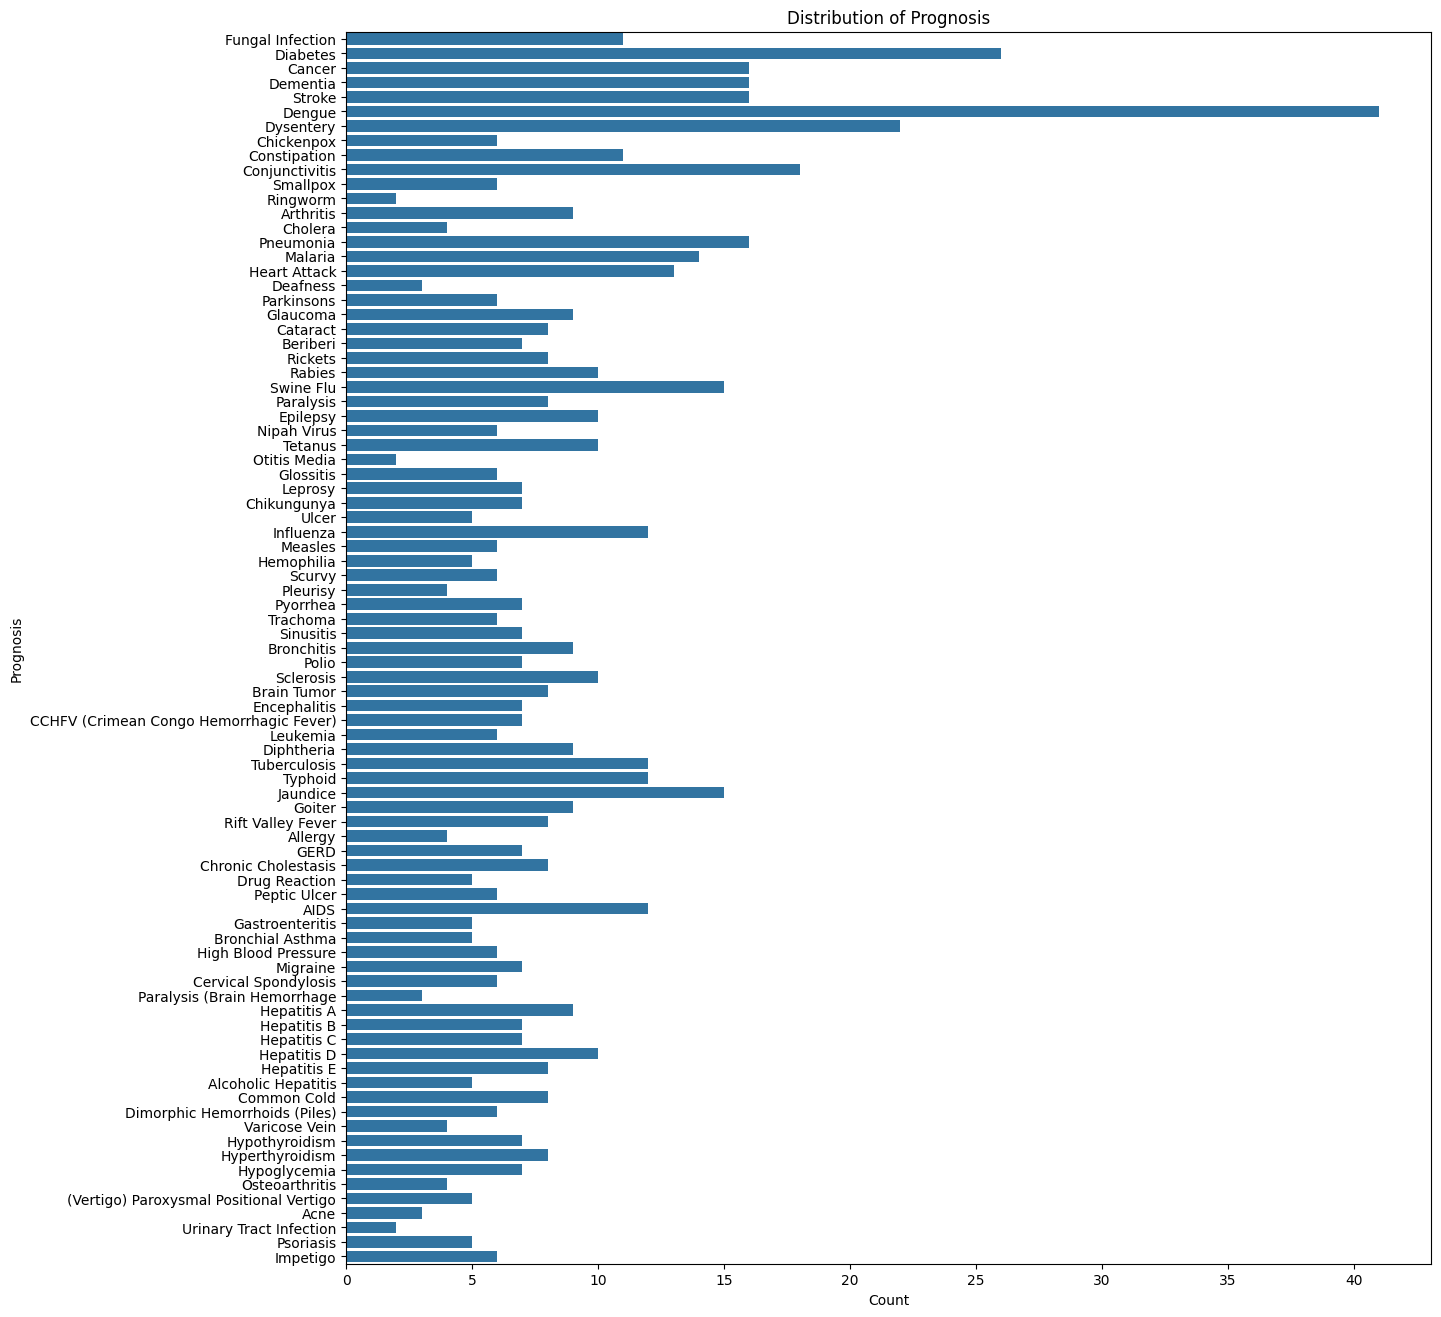

In [26]:
# Visualize the distribution of the target variable
plt.figure(figsize=(14, 16))
sns.countplot(y=df['Prognosis'])
plt.title('Distribution of Prognosis')
plt.xlabel('Count')
plt.ylabel('Prognosis')
plt.show()

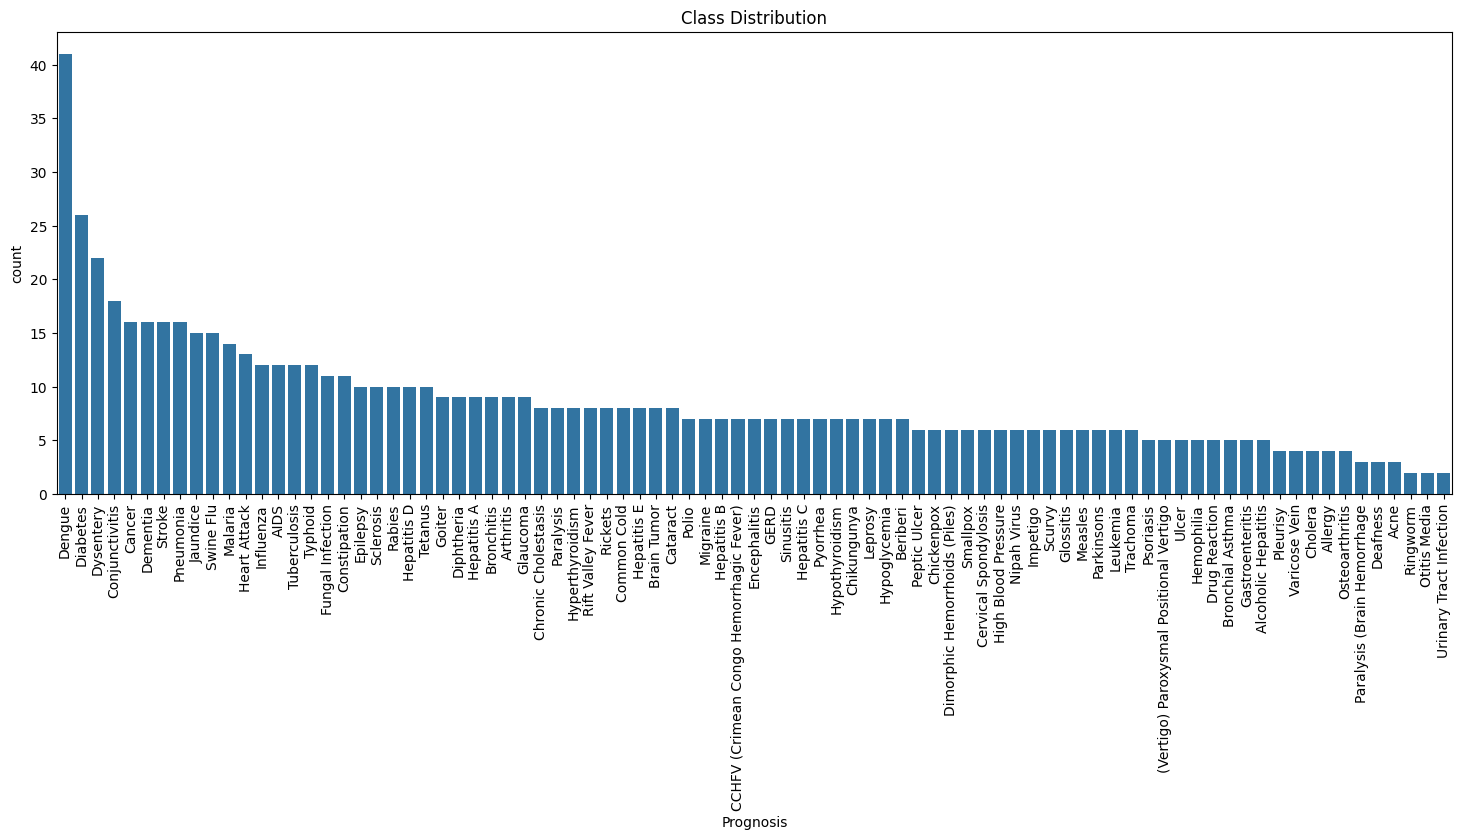

In [27]:
# Class Imbalance 
plt.figure(figsize=(18,6))
sns.countplot(data=df, x="Prognosis", order=df['Prognosis'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

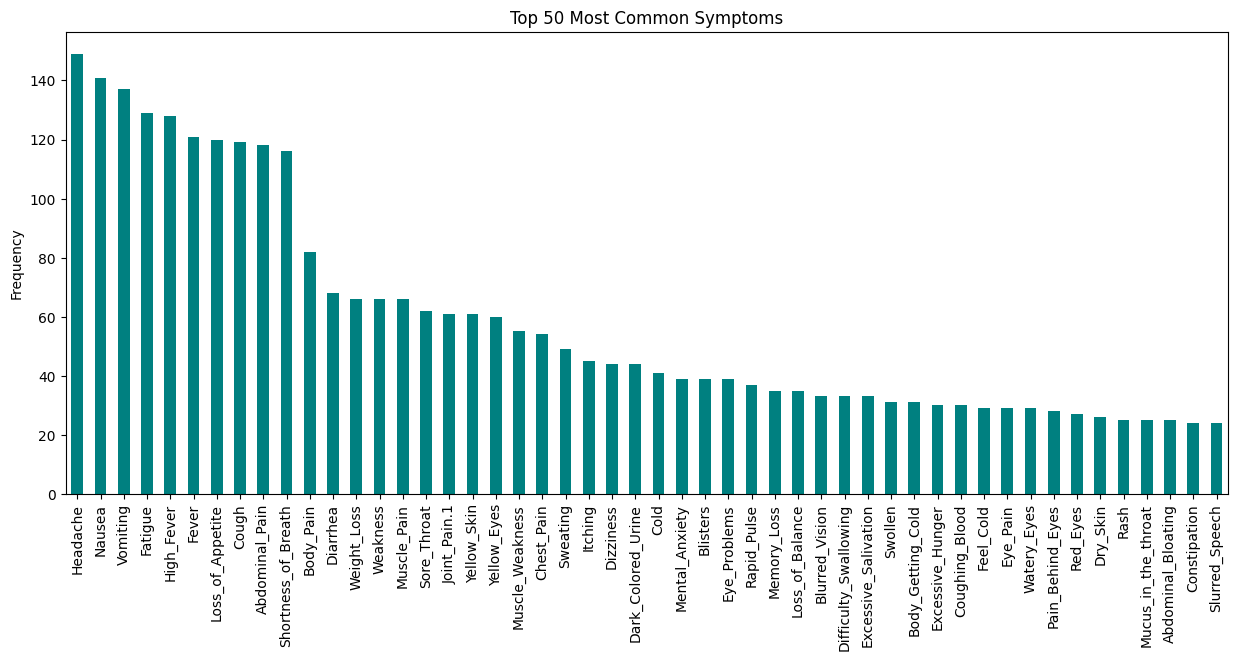

In [28]:
# Symptom Frequency
symptom_cols = df.drop("Prognosis", axis=1).columns
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
symptom_counts.head(50).plot(kind='bar', color="teal")
plt.title("Top 50 Most Common Symptoms")
plt.ylabel("Frequency")
plt.show()

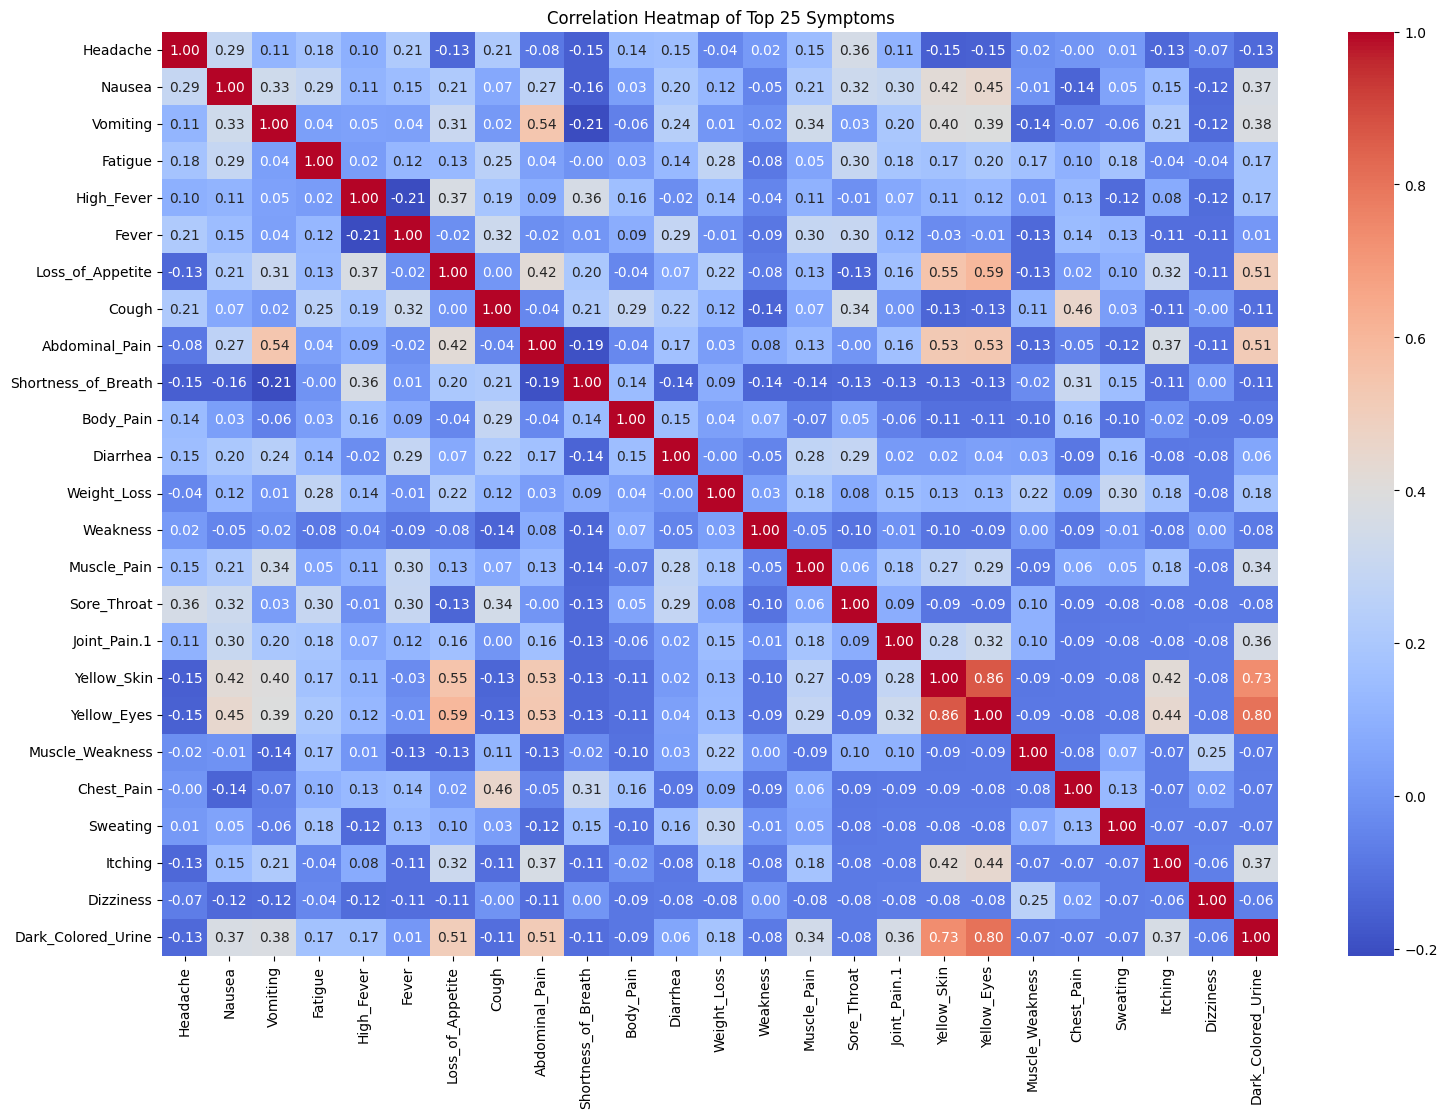

In [29]:
# Plot the Correlation Heatmap of Top 25 Symptoms 
# Find the top 25 most frequent symptoms
top_25_symptoms = df.drop('Prognosis', axis=1).sum().sort_values(ascending=False).head(25).index

# Create a correlation matrix for these symptoms
corr_matrix = df[top_25_symptoms].corr()
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top 25 Symptoms')
plt.show()

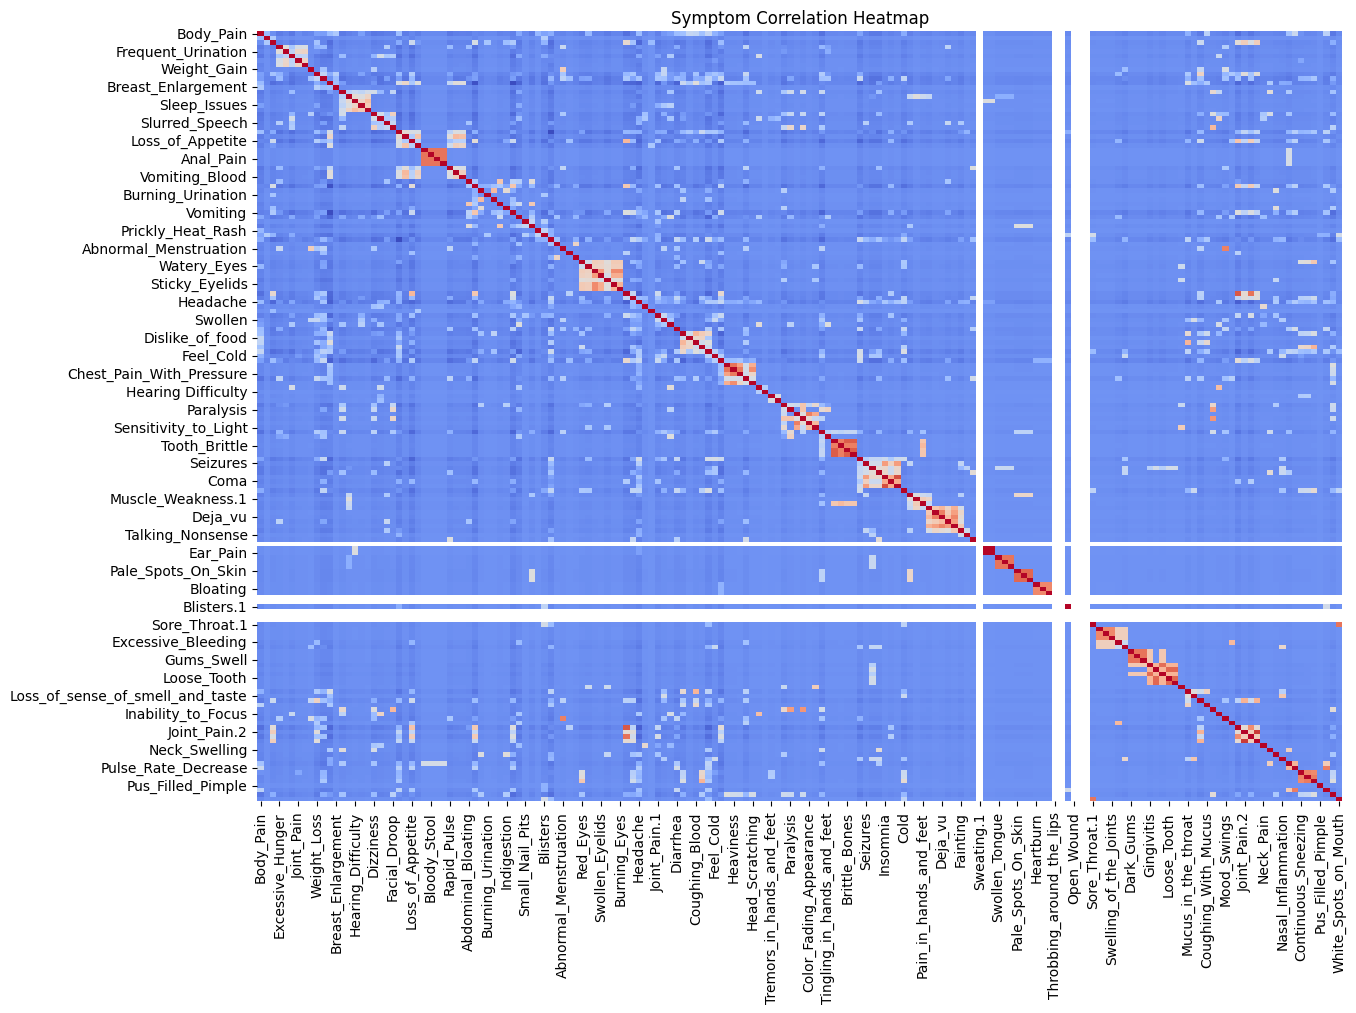

In [30]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
corr = df[symptom_cols].corr()
sns.heatmap(corr, cmap="coolwarm", cbar=False)
plt.title("Symptom Correlation Heatmap")
plt.show()

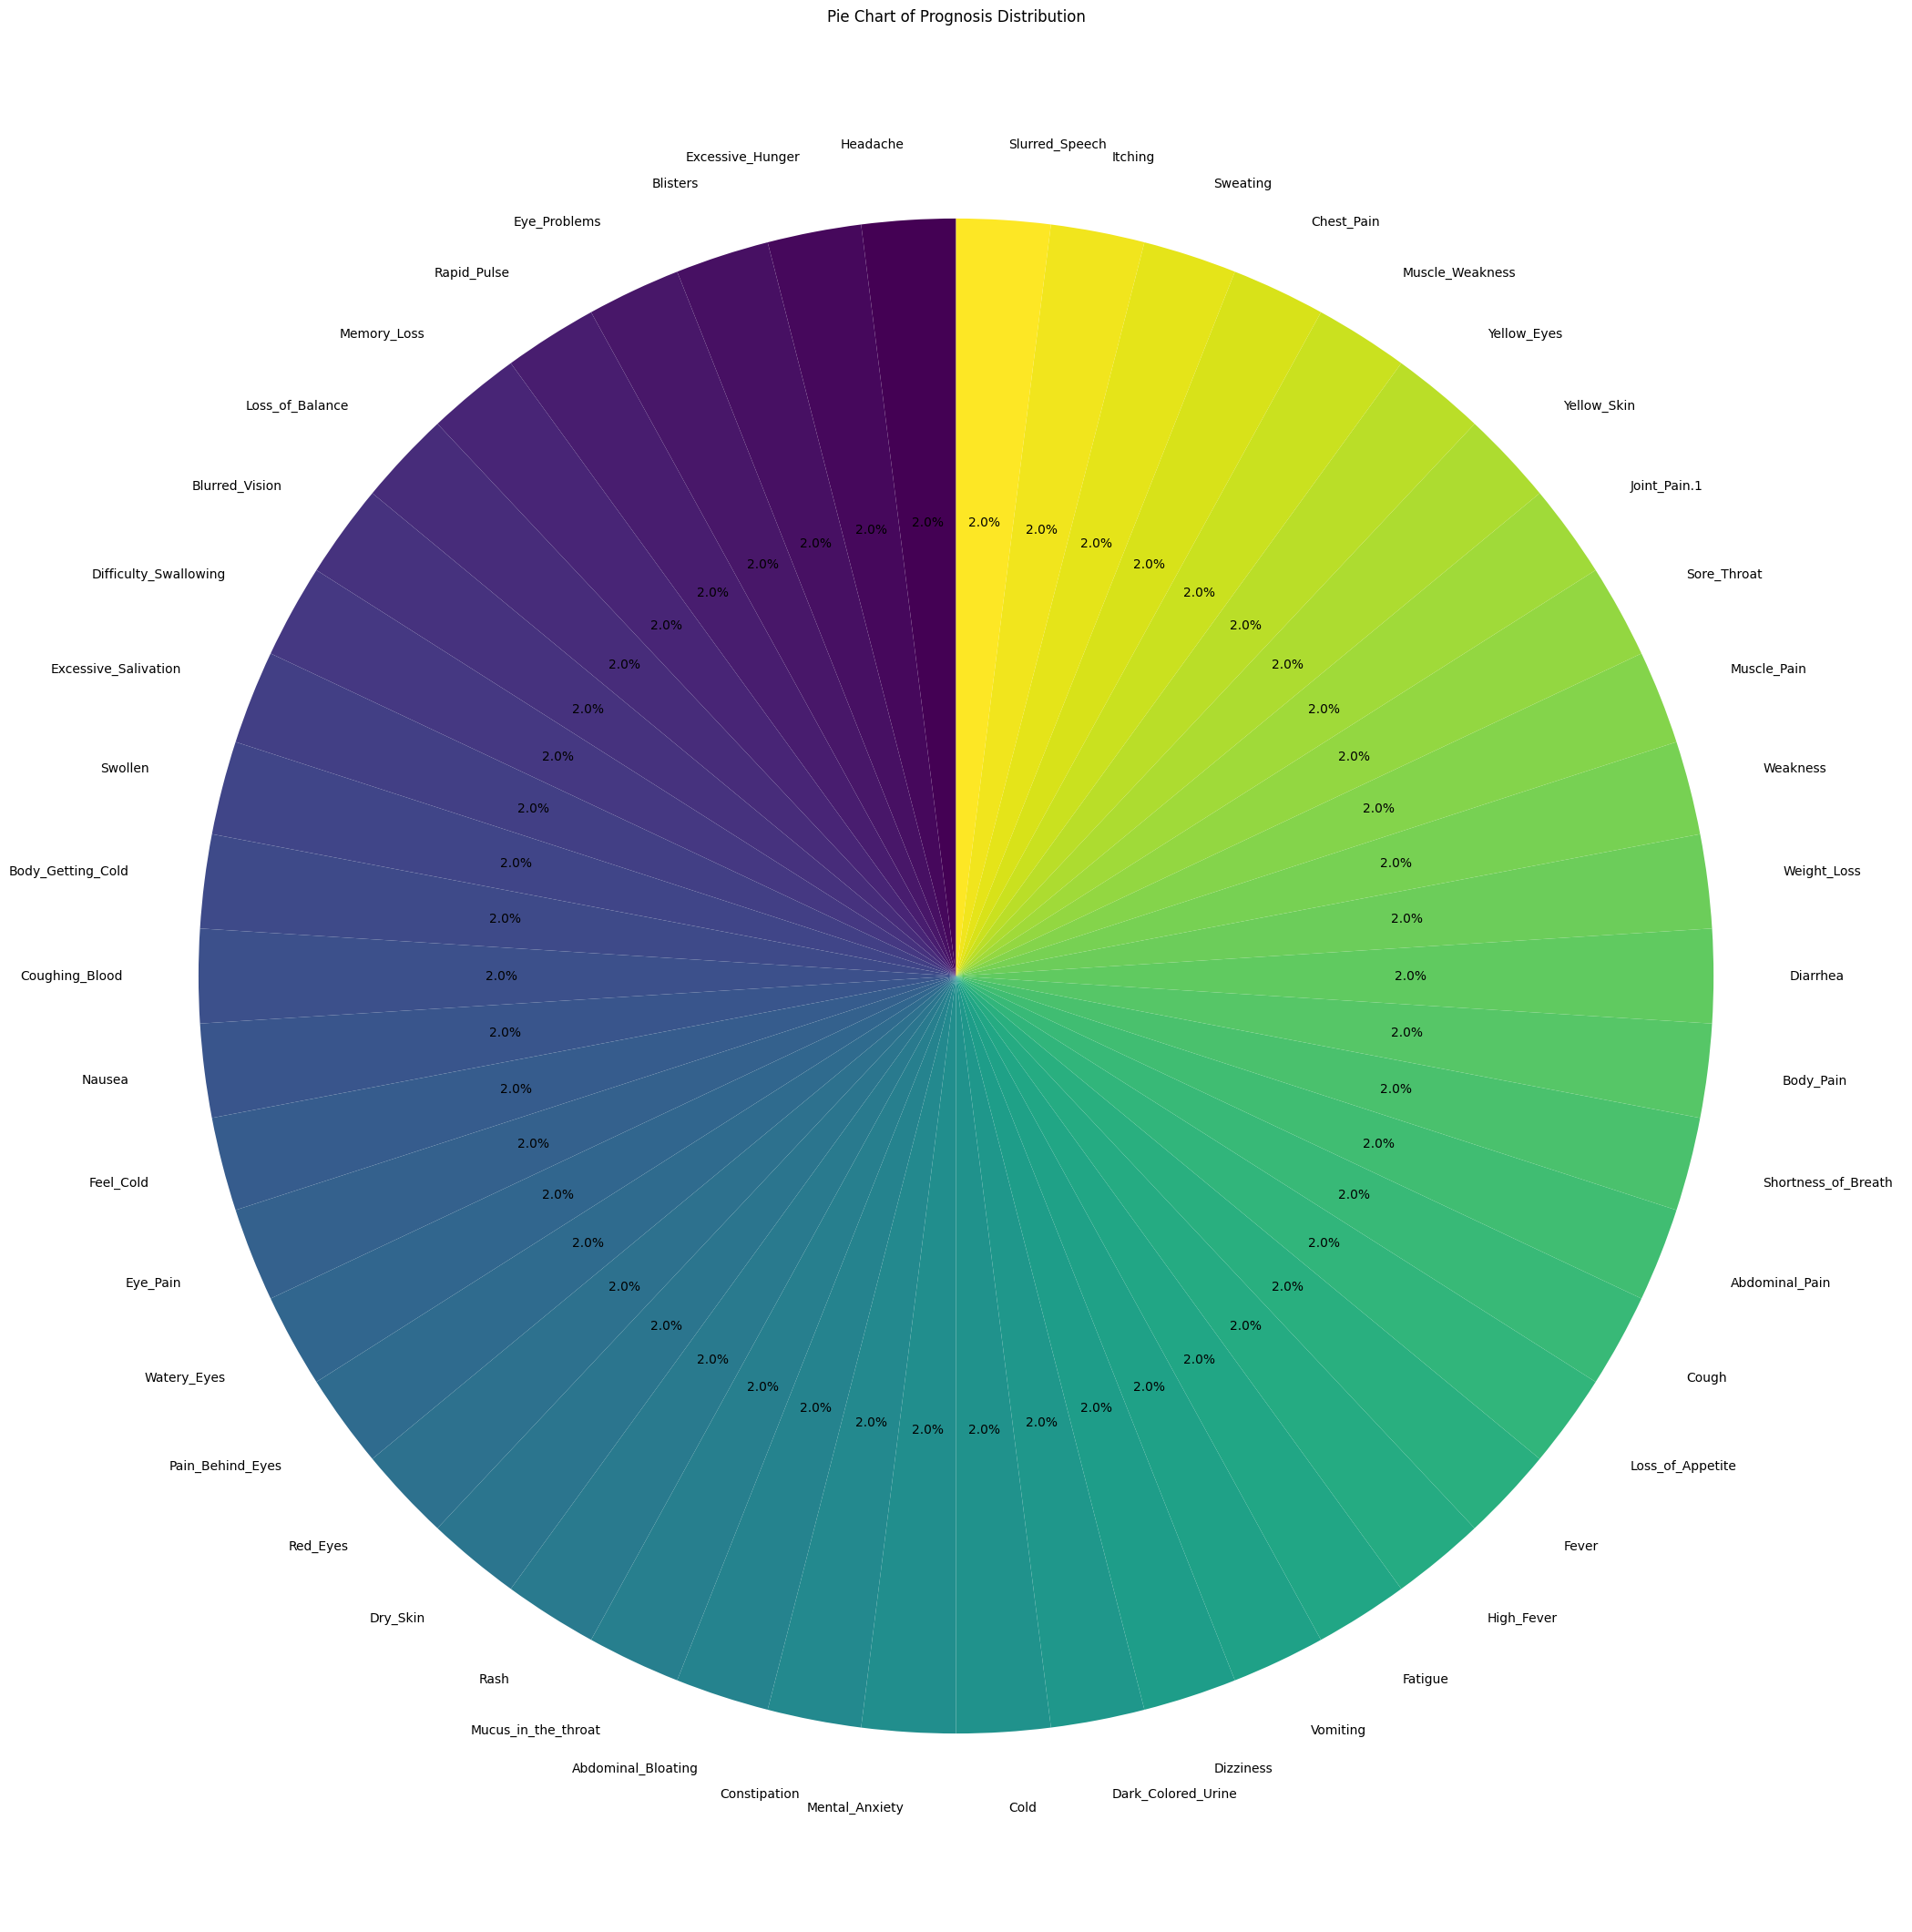

In [31]:
# Pie Chart of Prognosis Distribution
top_50= df.drop('Prognosis', axis=1).sum().sort_values(ascending=False).head(50).index

plt.figure(figsize=(27,27))
top_50.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Pie Chart of Prognosis Distribution')
plt.ylabel('') # Hide the y-label
plt.show()

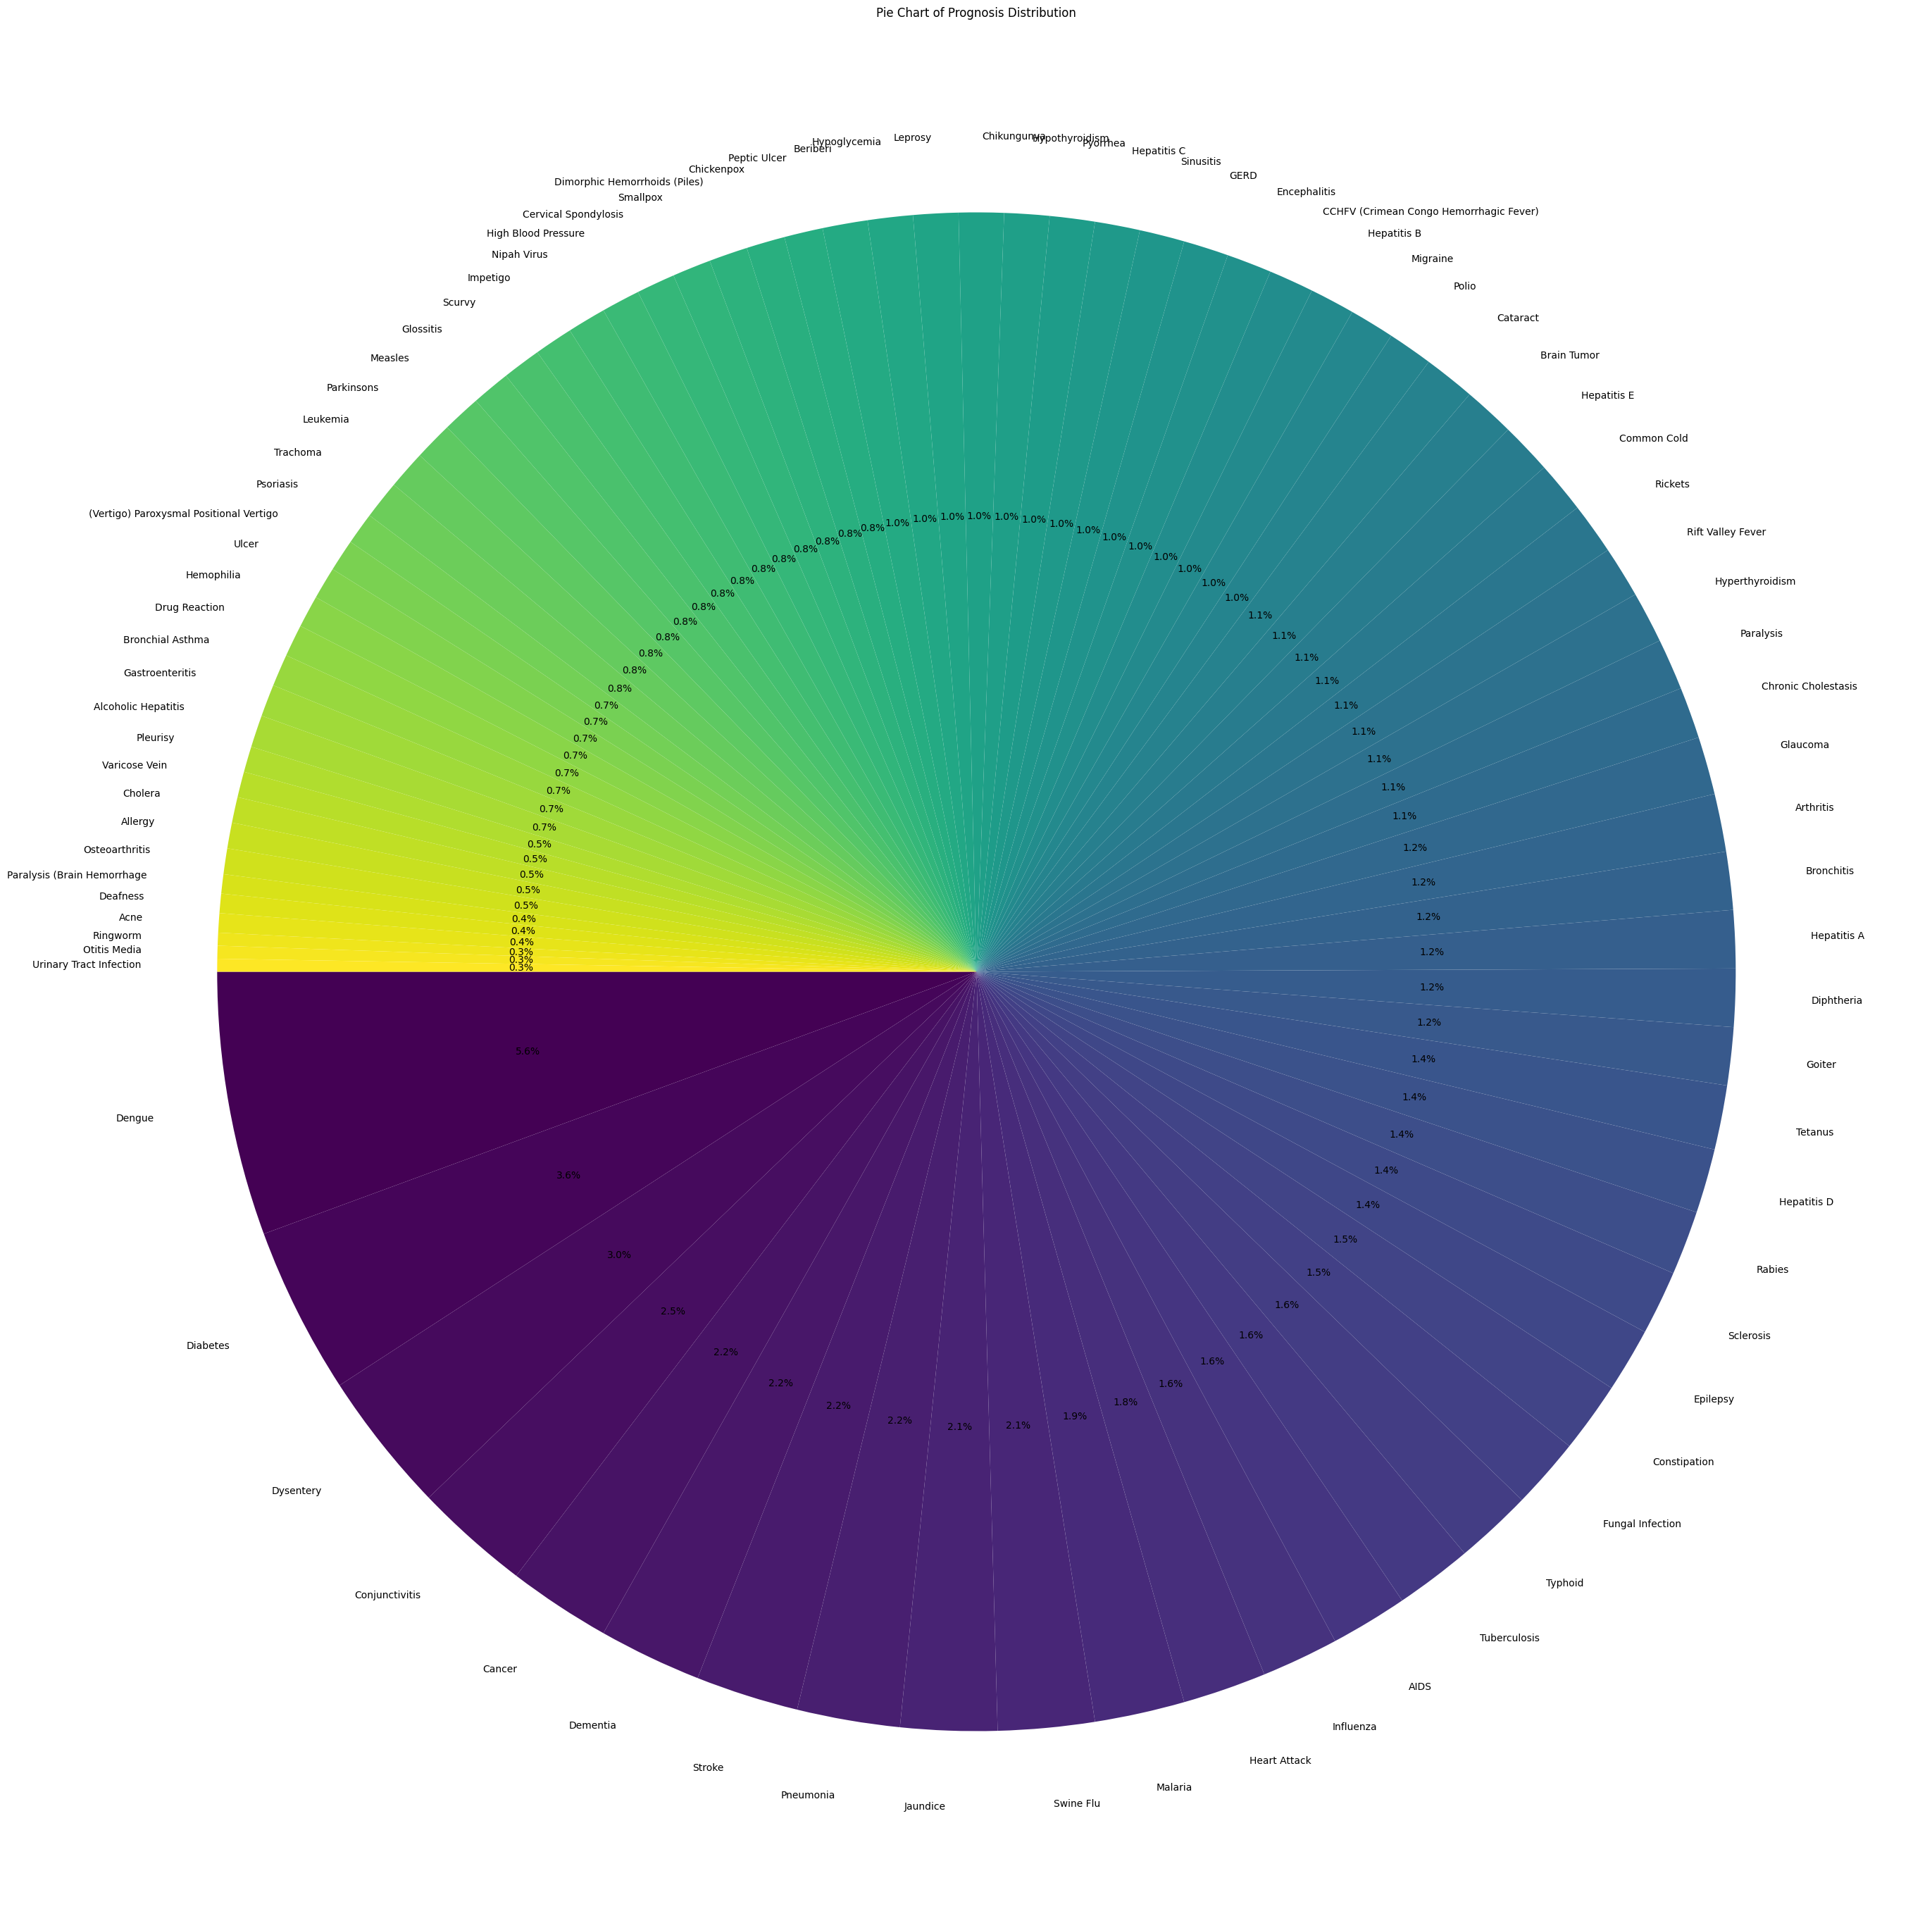

In [32]:
# Pie Chart of Prognosis Distribution
plt.figure(figsize=(35, 35))
df['Prognosis'].value_counts().plot.pie(autopct='%1.1f%%', startangle=180, cmap='viridis')
plt.title('Pie Chart of Prognosis Distribution')
plt.ylabel('') # Hide the y-label
plt.show()

In [33]:
# Separate features and target
X = df.drop('Prognosis', axis=1)
y = df['Prognosis']

# Encode the target variable 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nFeatures separated and target variable encoded.")


Features separated and target variable encoded.


In [34]:
# Data Splitting 
print("\n--- Data Splitting ---")

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


--- Data Splitting ---
X_train shape: (584, 172)
X_test shape: (147, 172)
y_train shape: (584,)
y_test shape: (147,)


In [35]:
# # Handling Class Imbalance with BorderlineSMOTE
# print("Original training data shape %s" % Counter(y_train))

# # 2. Initialize BorderlineSMOTE (Robust for single-sample classes)
# # k_neighbors=1 and sampling_strategy='not majority' skips singleton classes
# bsm = BorderlineSMOTE(
#     random_state=42, 
#     sampling_strategy='not majority', 
#     k_neighbors=1, 
#     m_neighbors=10 # Default parameter
# )

# # 3. Apply BorderlineSMOTE to the training data only
# X_res, y_res = bsm.fit_resample(X_train, y_train)

# # 4. Check the new balanced class distribution
# print("Resampled training data shape %s" % Counter(y_res))

# # 5. Overwrite the original training variables for Cell 15 to use
# X_train = X_res
# y_train = y_res

# print("\nTraining data has been successfully balanced, ignoring singleton classes.")


--- Model Training and Hyperparameter Tuning ---

--- Training Decision Tree ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for Decision Tree: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_split': 2}

Accuracy for Decision Tree: 0.3946
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.12      1.00      0.22         1
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         1
           7       1.00      0.50      0.67         2
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11   

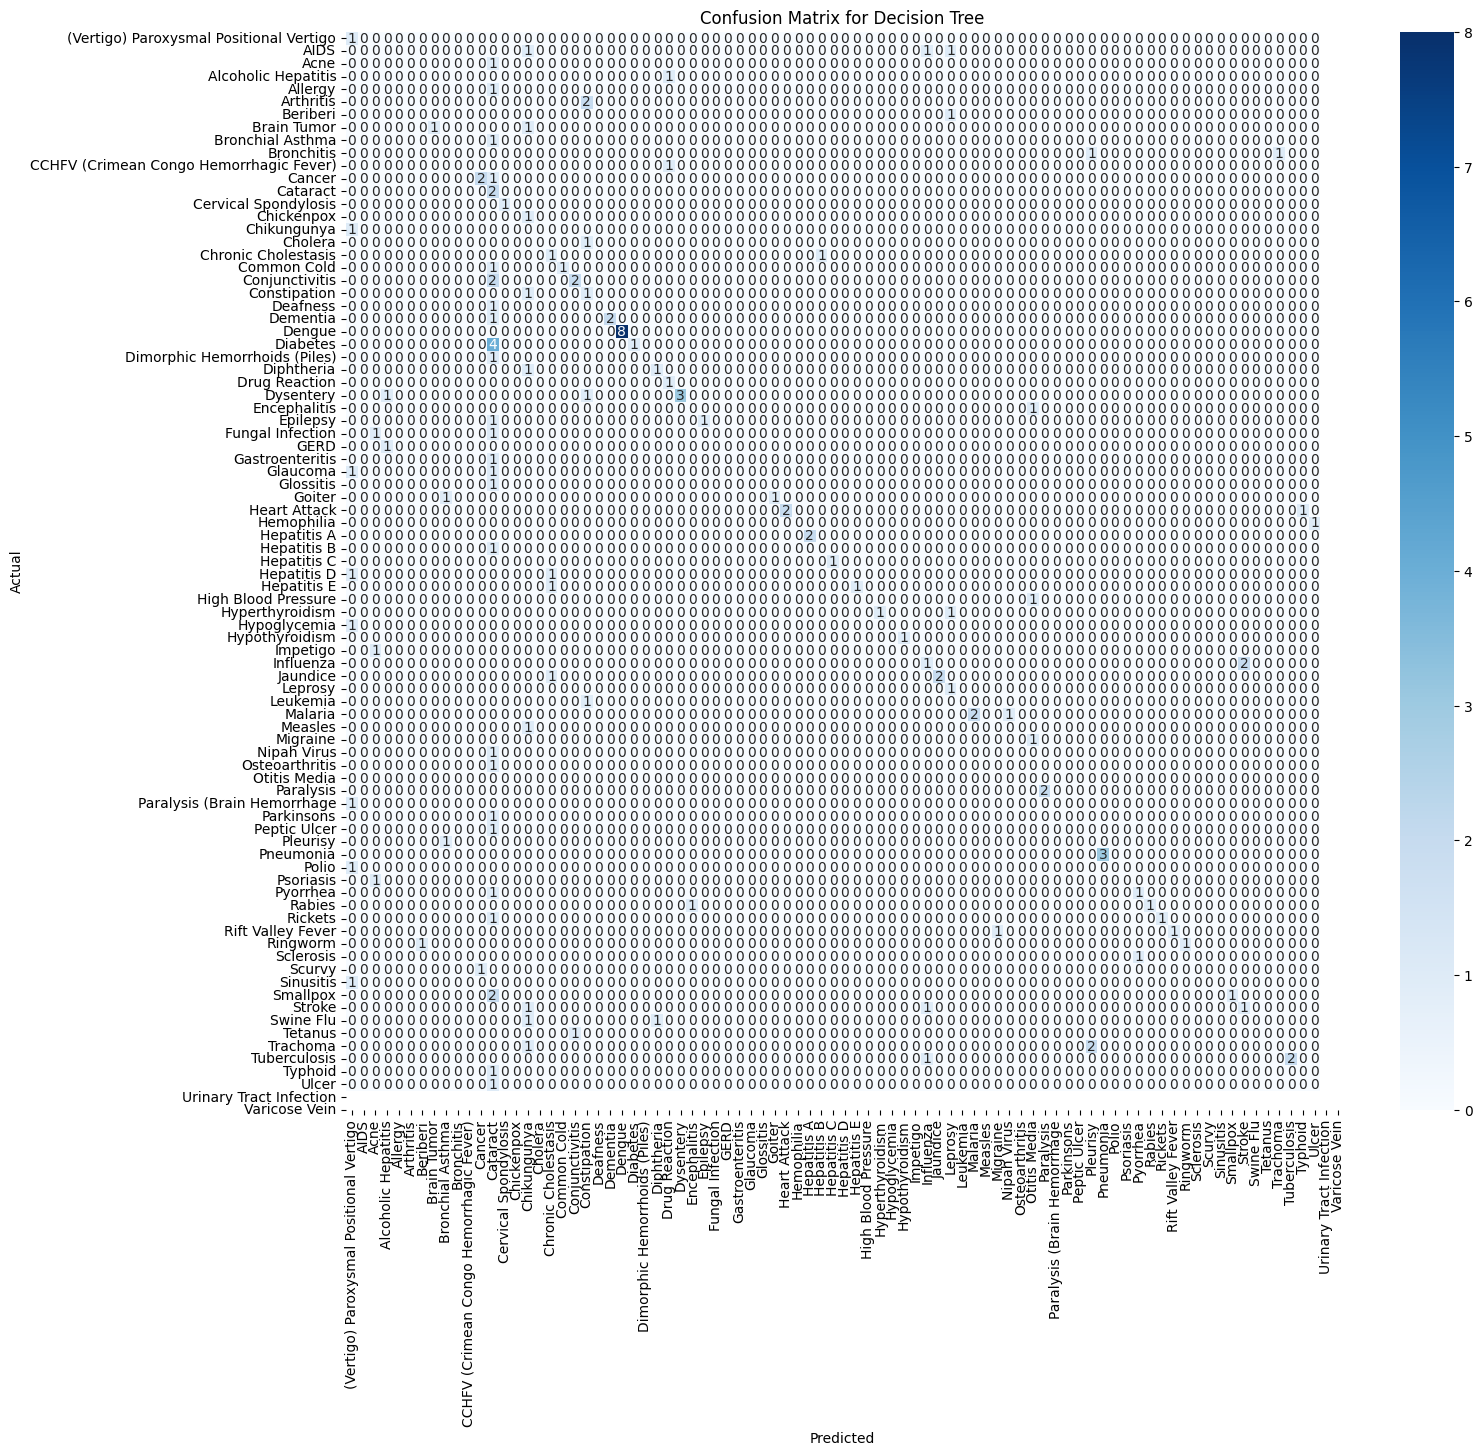


--- Training Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Random Forest: {'clf__max_depth': 15, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}

Accuracy for Random Forest: 0.9660
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         3
          12  

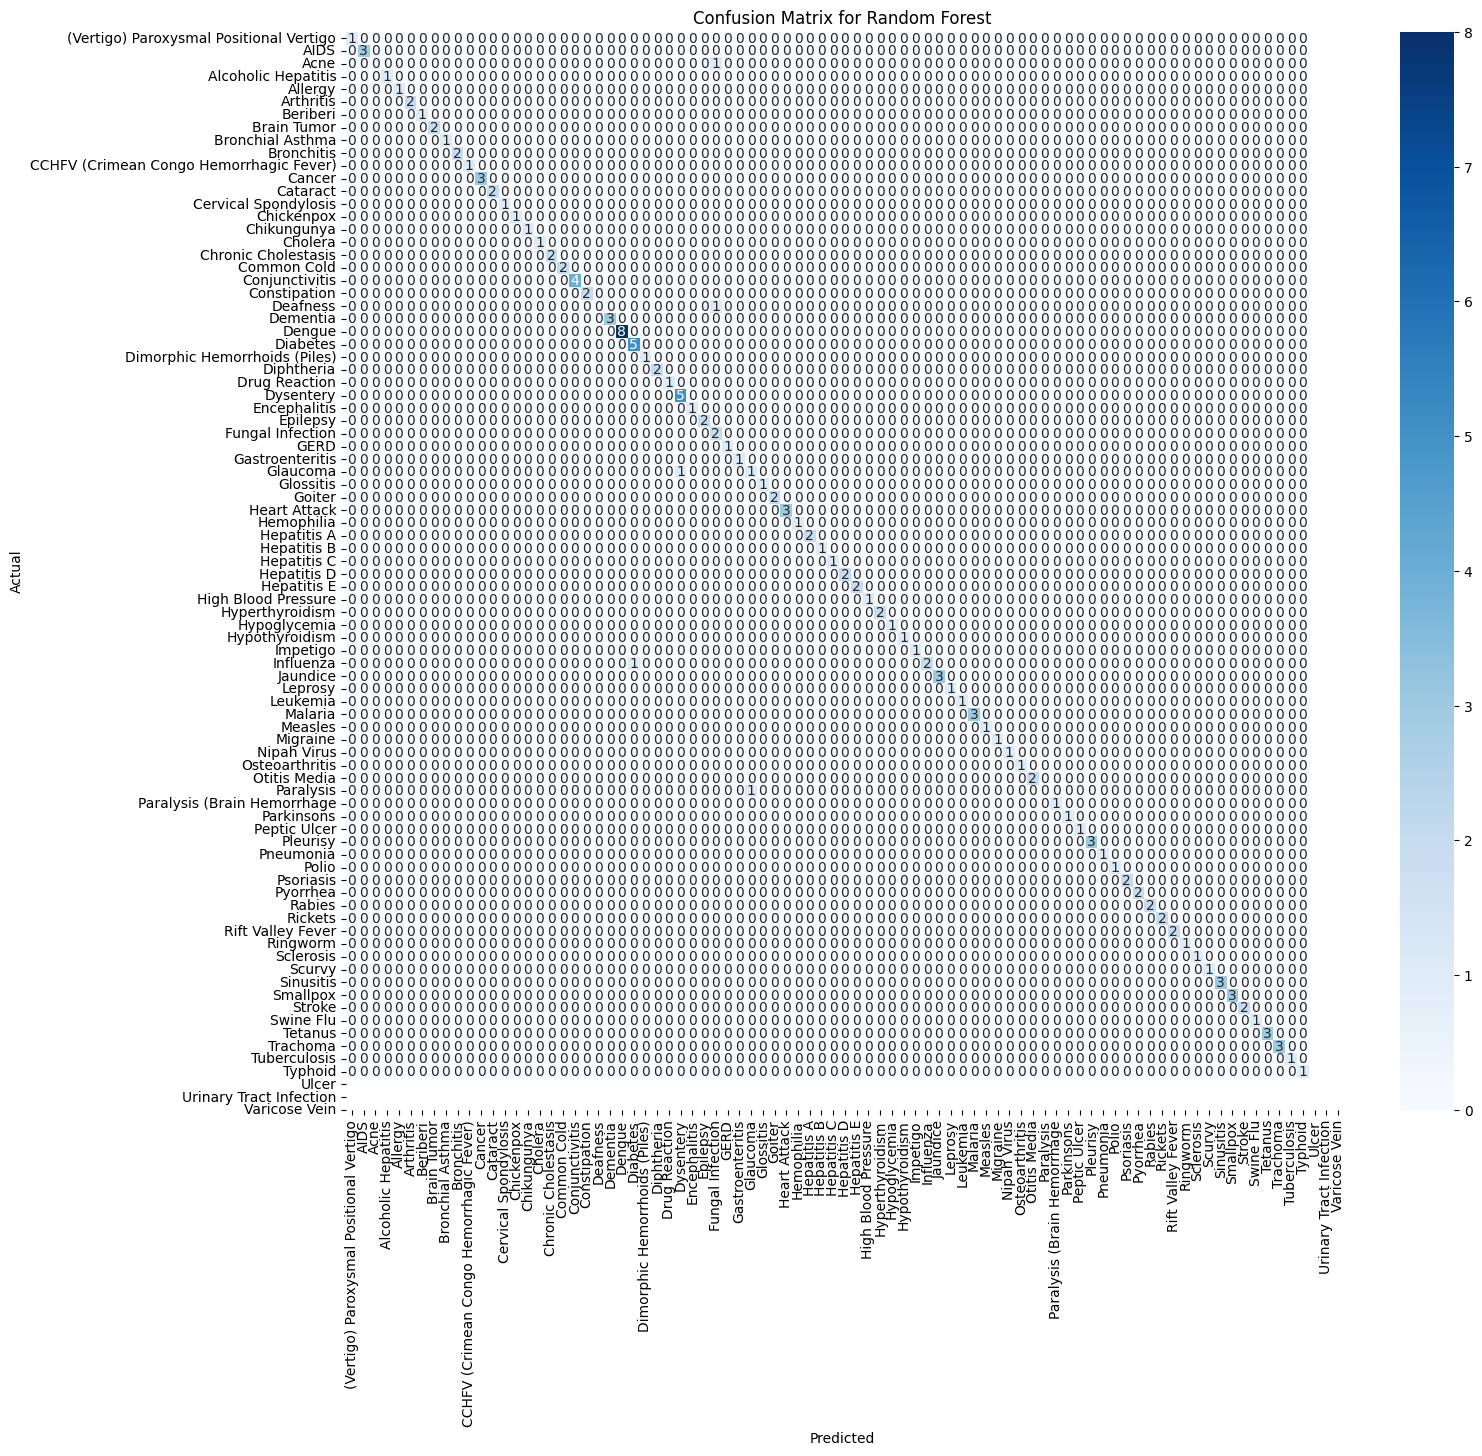


--- Training XGBoost ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for XGBoost: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}

Accuracy for XGBoost: 0.7551
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         1
           7       1.00      0.50      0.67         2
           8       0.50      1.00      0.67         1
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         3
          12       0.67      1.00      0.

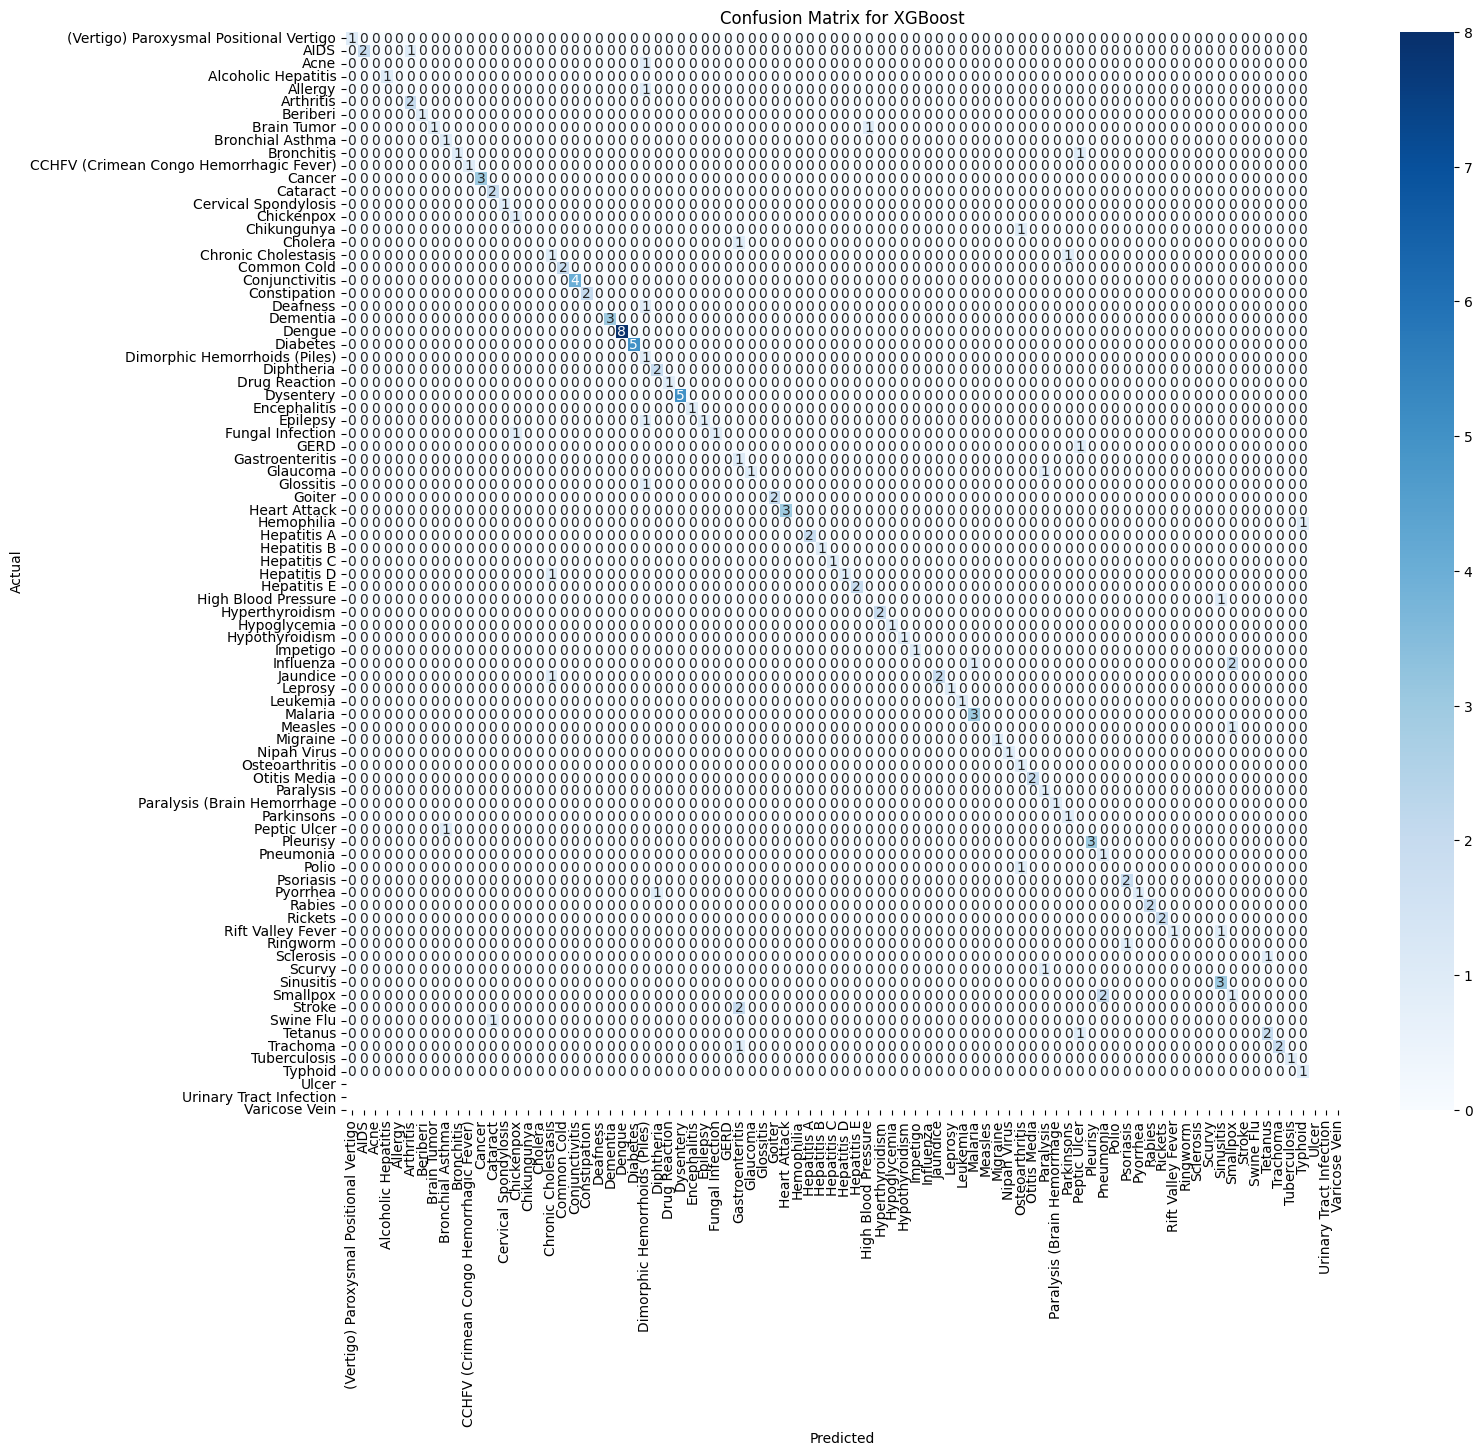

: 

In [ ]:
print("\n--- Model Training and Hyperparameter Tuning ---")

# Define pipelines for each model (FIXED: StandardScaler removed for tree models)
pipeline_dt = Pipeline([
    # Removed StandardScaler because tree models don't need scaling on binary data
    ('clf', DecisionTreeClassifier(random_state=42)) 
])

pipeline_rf = Pipeline([
    # Removed StandardScaler because tree models don't need scaling on binary data
    ('clf', RandomForestClassifier(random_state=42)) 
])

# XGBoost still uses StandardScaler as it can sometimes benefit
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

# Define hyperparameter grids (FIXED: Max depth reduced for complexity control)
param_grid_dt = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [5, 10, 15], # Reduced max depth from [None, 10, 20, 30]
    'clf__min_samples_split': [2, 5, 10]
}

param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10, 15], # Reduced max depth from [None, 10, 20]
    'clf__min_samples_split': [2, 5]
}

# XGBoost grid remains the same
param_grid_xgb = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7]
}

# Create a list of pipelines and their parameter grids
pipelines = [pipeline_dt, pipeline_rf, pipeline_xgb]
param_grids = [param_grid_dt, param_grid_rf, param_grid_xgb]
model_names = ['Decision Tree', 'Random Forest', 'XGBoost']
results = {}
best_estimators = {}

# Loop through each model to perform GridSearchCV
for i, (pipeline, param_grid) in enumerate(zip(pipelines, param_grids)):
    print(f"\n--- Training {model_names[i]} ---")
    
    # Now training on the SMOTE-resampled data (X_train, y_train)
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_estimators[model_names[i]] = best_model
    
    print(f"Best parameters for {model_names[i]}: {grid_search.best_params_}")
    
    # Evaluate the best model on the TEST set (X_test, original data)
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[model_names[i]] = accuracy
    
    print(f"\nAccuracy for {model_names[i]}: {accuracy:.4f}")
    print(f"Classification Report for {model_names[i]}:\n{classification_report(y_test, y_pred)}")
    
    # Plot confusion matrix (unchanged)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.inverse_transform(best_model.classes_), yticklabels=le.inverse_transform(best_model.classes_))
    plt.title(f'Confusion Matrix for {model_names[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


--- Model Comparison ---
           Model  Accuracy
1  Random Forest  0.931973
2        XGBoost  0.755102
0  Decision Tree  0.401361


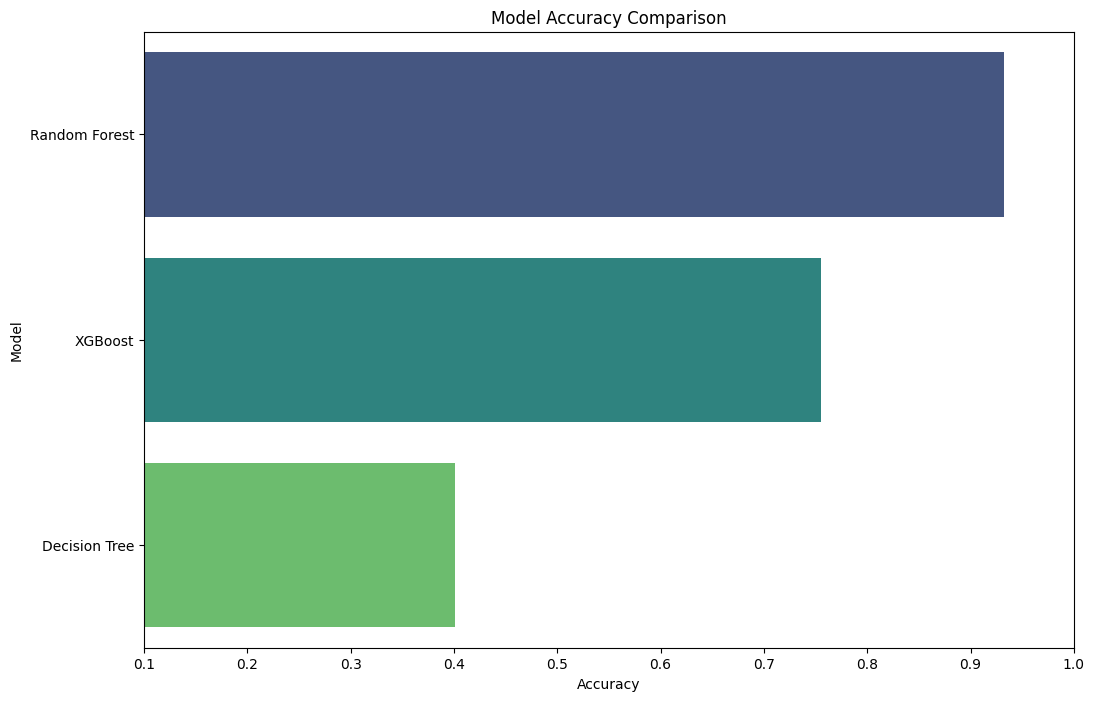

In [37]:
# --- 5. Model Comparison ---
print("\n--- Model Comparison ---")
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df)

plt.figure(figsize=(12, 8))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.1, 1.0)
plt.show()

In [38]:
# Find the best model from the results
best_model_name = results_df.iloc[0]['Model']
best_model_to_save = best_estimators[best_model_name]

# Create a dictionary to save all necessary objects
model_data = {
    'model': best_model_to_save,
    'columns': X.columns,
    'label_encoder': le
}

print(f"\nSaving the best model and required objects: {best_model_name}")

# Save the dictionary to a file
filename = '../backend/Ai_model/model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model_data, file)

print(f"Model and objects saved to {filename}")


Saving the best model and required objects: Random Forest
Model and objects saved to ../backend/Ai_model/model.pkl


In [39]:
# Predict Disease from Symptoms ---
def predict_disease_from_file(symptoms):
    """
    Predicts the disease based on a list of symptoms by loading all required objects from a file.
    
    Args:
        symptoms (list): A list of symptom strings.
    """
    # Load the saved model and other objects
    with open('../backend/Ai_model/model.pkl', 'rb') as file:
        model_data = pickle.load(file)
    
    loaded_model = model_data['model']
    feature_columns = model_data['columns']
    label_encoder = model_data['label_encoder']
    
    # Create a zero-filled dataframe with the same columns
    test_df = pd.DataFrame(columns=feature_columns)
    test_df.loc[0] = 0
    
    # Set the symptom columns to 1
    for symptom in symptoms:
        if symptom in feature_columns:
            test_df[symptom] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not found in training data and will be ignored.")

    # Ensure the columns are in the same order as during training
    test_df = test_df[feature_columns]
    
    # Make prediction
    pred_label = loaded_model.predict(test_df)[0]
    
    # Decode the label back to the original class name
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    
    return pred_class


# Example usage:
my_symptoms = ['Vomiting', 'Chest_Pain']
predicted_disease = predict_disease_from_file(my_symptoms)
print(f"\nBased on your symptoms, the predicted disease is: {predicted_disease}")


Based on your symptoms, the predicted disease is: Pleurisy


In [40]:
# Summary 
summary = {
    "dataset_shape": df.shape,
    "num_symptoms": len(symptom_cols),
    "num_diseases": df['Prognosis'].nunique(),
    "most_common_disease": df['Prognosis'].value_counts().idxmax(),
    "least_common_disease": df['Prognosis'].value_counts().idxmin(),
    "most_common_symptom": symptom_counts.idxmax(),
    "least_common_symptom": symptom_counts.idxmin()
}
print("\nSummary Stats:\n", summary)


Summary Stats:
 {'dataset_shape': (731, 173), 'num_symptoms': 172, 'num_diseases': 85, 'most_common_disease': 'Dengue', 'least_common_disease': 'Ringworm', 'most_common_symptom': 'Headache', 'least_common_symptom': 'Sweating.1'}
